In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df.shape

(301355, 5)

Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
grouped_df

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
...,...,...
200,2018-08-26,5302
201,2018-08-28,5983
202,2018-08-29,4969
203,2018-08-30,4648


Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

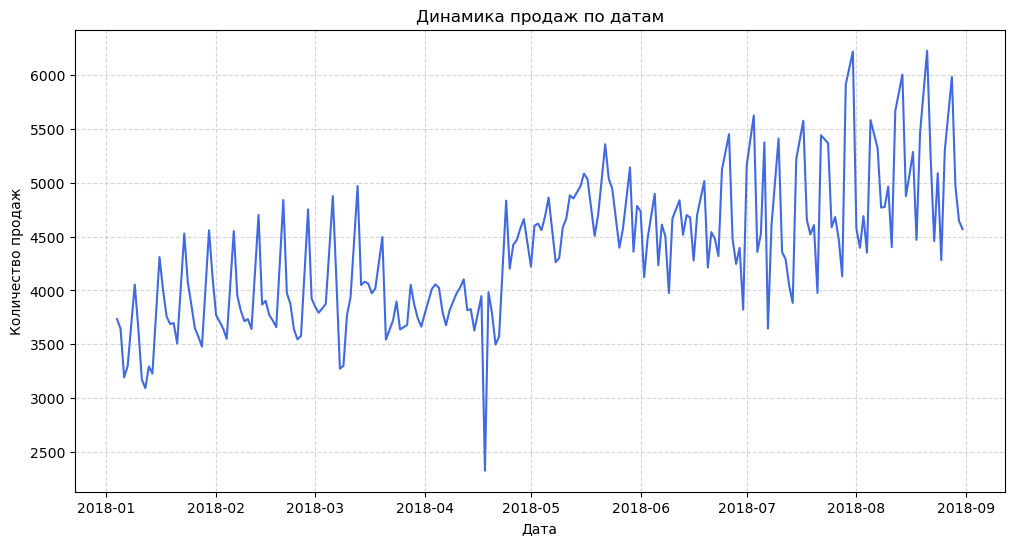

In [8]:
plt.figure(figsize = (12, 6))

plt.plot(grouped_df['Дата'], grouped_df['Количество'], color = 'royalblue')
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**Ответ:** <br>
На полученном графике мы можем видеть динамику количества продаж за период с января по август 2018 года.<br>
По оси Х указаны даты с шагом в 1 месяц.<br>
По оси Y указано суммарное количество проданных товаров за день.<br>

На графике четко прослеживается общая тенденция к росту продаж на протяжении всего рассматриваемого периода. Это говорит о стабильном увеличении спроса, расширении бизнеса к августу 2018 года.<br>
Пики продаж скорее всего приходятся на определенные дни недели, когда клиенты совершают массовые покупки.<br>
    
Главная аномалия тренда - резкий провал в середине апреля.<br>
До середины марта продажи шли системно и постепенно нарастали, в апреле случился резкий спад, с июля продажи снова пошли вверх.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
max_value = df["Количество"].max()
max_row = df[df["Количество"] == max_value]

print(f"Максимальное количество в одной продаже: {max_value}")
max_row

Максимальное количество в одной продаже: 200


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


In [10]:
#Или же спользую метод межквартильного размаха для поиска выбросов:
q1 = df['Количество'].quantile(0.25)
q3 = df['Количество'].quantile(0.75)
IQR = q3 - q1

upper_boundary = q3 + 1.5 * IQR
outliers = df[df['Количество'] > upper_boundary]

max_outlier_row = outliers.loc[[outliers['Количество'].idxmax()]]

print(f"Верхняя граница нормы: {upper_boundary}")
print(f"Всего строк c выбросами обнаружено: {len(outliers)}")
print("\nСтрока с максимальным выбросом:")
max_outlier_row

Верхняя граница нормы: 8.5
Всего строк c выбросами обнаружено: 13140

Строка с максимальным выбросом:


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
df_sklad3 = df[df["Склад"] == 3]

df_summer = df_sklad3[(df_sklad3["Дата"].dt.month >= 6) & (df_sklad3["Дата"].dt.month <= 8)]

df_wednesdays = df_summer[df_summer["Дата"].dt.dayofweek == 2]

top_products = df_wednesdays.groupby("Номенклатура", as_index = False)["Количество"].sum()

top_products = top_products.sort_values(by = "Количество", ascending = False)
print("Топовый товар по продажам по средам за лето на 3 складе:")
top_products.head(1)

Топовый товар по продажам по средам за лето на 3 складе:


,Номенклатура,Количество
1,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [12]:
weather_df = pd.read_csv("Блок Python - Погода Астана январь-август 2018.csv", sep = ";", encoding = "cp1251", decimal = ",")

In [13]:
weather_df.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


In [14]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Местное время в Астане  1918 non-null   object 
 1   T                       1918 non-null   float64
 2   Po                      1918 non-null   float64
 3   P                       1918 non-null   float64
 4   Pa                      1915 non-null   float64
 5   U                       1917 non-null   float64
 6   DD                      1918 non-null   object 
 7   Ff                      1918 non-null   int64  
 8   ff10                    15 non-null     float64
 9   ff3                     51 non-null     float64
 10  N                       1916 non-null   object 
 11  WW                      1918 non-null   object 
 12  W1                      689 non-null    object 
 13  W2                      689 non-null    object 
 14  Tn                      240 non-null    

In [15]:
weather_df["DateTime"] = pd.to_datetime(weather_df["Местное время в Астане"], format="%d.%m.%Y %H:%M")

In [16]:
#Уберу из столбца информацию о времени:
weather_df["Дата"] = weather_df["DateTime"].dt.date

In [17]:
#Сгруппируюпо дате и найду среднесуточную температуру T:
daily_weather = weather_df.groupby("Дата", as_index=False)["T"].mean()

In [18]:
#Столбец 'Дата' приведу к типу datetime64 для объединения
daily_weather["Дата"] = pd.to_datetime(daily_weather["Дата"])

In [19]:
#Объединяем продажи и погоду по дате:
merged_df = pd.merge(grouped_df, daily_weather, on="Дата", how="inner")

In [20]:
merged_df = merged_df.sort_values("Дата")

In [21]:
plot_df = merged_df.set_index("Дата")

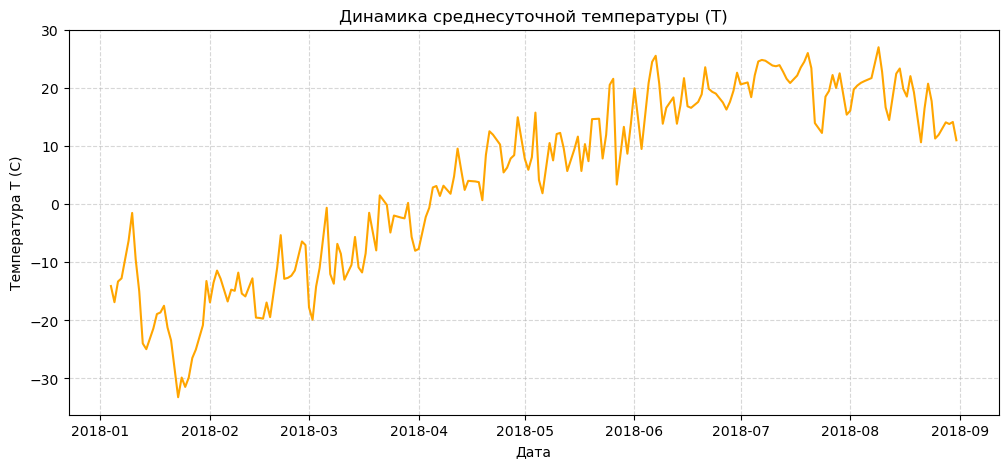

In [22]:
#Отдельный график температуры
plt.figure(figsize = (12, 5))
plt.plot(plot_df.index, plot_df["T"], color="orange")
plt.title("Динамика среднесуточной температуры (T)")
plt.xlabel("Дата")
plt.ylabel("Температура T (С)")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

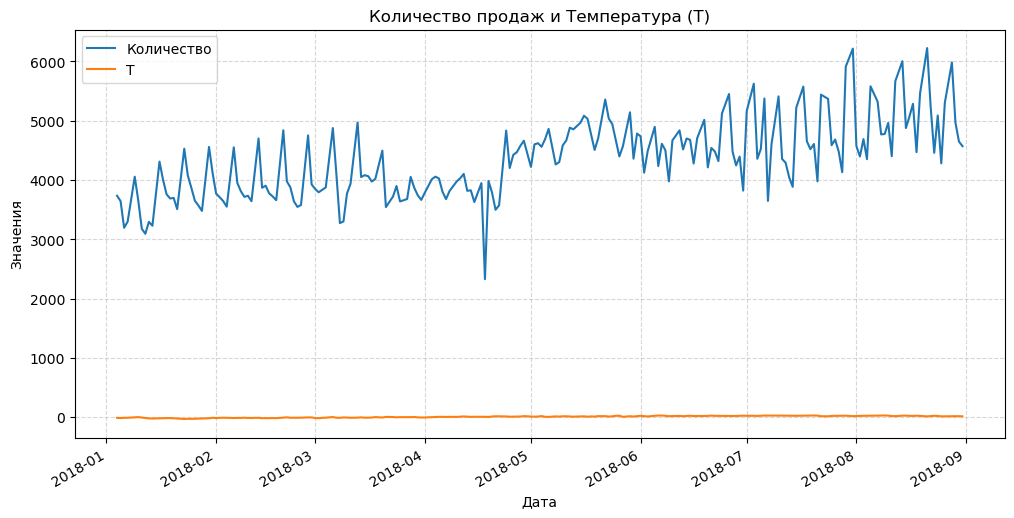

In [23]:
#Совмещенный график y=['Количество продаж', 'T']:
plot_df[["Количество", "T"]].plot(figsize=(12, 6))
plt.title("Количество продаж и Температура (T)")
plt.xlabel("Дата")
plt.ylabel("Значения")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

In [24]:
#Как мы видим, линия Температуры получилась почти ровной из-за проблемы масштаба, построим график с двойной осью Y:

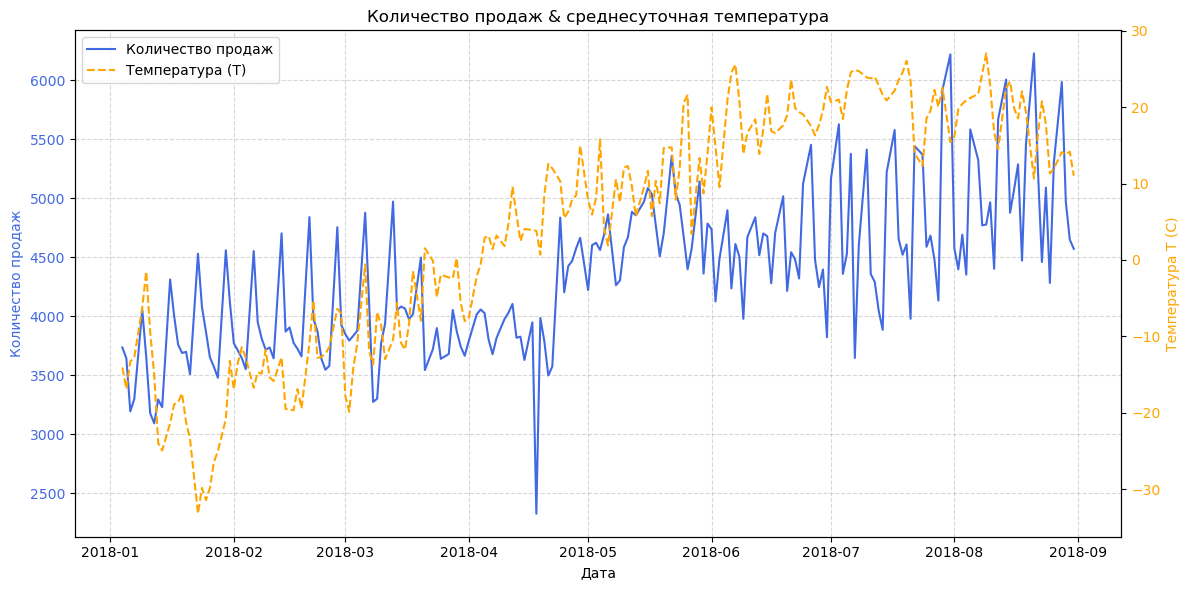

In [25]:
fig, ax1 = plt.subplots(figsize = (12, 6))

#Линия - Количество продаж (синий)
ax1.set_xlabel("Дата")
ax1.set_ylabel("Количество продаж", color = "royalblue")
line1 = ax1.plot(
    merged_df["Дата"],
    merged_df["Количество"],
    color = "royalblue",
    label="Количество продаж",)
ax1.tick_params(axis = "y", labelcolor = "royalblue")
ax1.grid(True, linestyle = "--", alpha = 0.5) 

#Создаем вторую ось Y - для шкалы температуры
ax2 = ax1.twinx()

#Линия - Температура (оранжевый)
ax2.set_ylabel("Температура T (C)", color = "orange")
line2 = ax2.plot(
    merged_df["Дата"],
    merged_df["T"],
    color = "orange",
    linestyle = "--",
    label = "Температура (T)",)
ax2.tick_params(axis = "y", labelcolor = "orange")

all_lines = line1 + line2
all_labels = [line.get_label() for line in all_lines]
ax1.legend(all_lines, all_labels, loc = "upper left")

plt.title("Количество продаж & среднесуточная температура")
plt.tight_layout()
plt.show()